# Comprehensive Retail Analytics: 
## Data Cleaning, EDA, and Customer Behavior Analysis

In [1]:
# Installing libraries

import pandas as pd

In [2]:
# Importing Data

trxn = pd.read_csv("Retail_Data_Transactions.csv")
trxn

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78
...,...,...,...
124995,CS8433,26-Jun-11,64
124996,CS7232,19-Aug-14,38
124997,CS8731,28-Nov-14,42
124998,CS8133,14-Dec-13,13


In [3]:
rsp = pd.read_csv("Retail_Data_Response.csv")
rsp

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


# Exploratory Data Analysis

In [4]:
trxn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  125000 non-null  object
 1   trans_date   125000 non-null  object
 2   tran_amount  125000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


In [5]:
rsp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6884 entries, 0 to 6883
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  6884 non-null   object
 1   response     6884 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 107.7+ KB


In [6]:
df = pd.merge(trxn, rsp, on='customer_id', how='left')

In [7]:
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   customer_id  125000 non-null  object 
 1   trans_date   125000 non-null  object 
 2   tran_amount  125000 non-null  int64  
 3   response     124969 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.8+ MB


In [9]:
df.describe()

,tran_amount,response
count,125000.000000,124969.000000
mean,64.991912,0.110763
std,22.860006,0.313840
min,10.000000,0.000000
25%,47.000000,0.000000
50%,65.000000,0.000000
75%,83.000000,0.000000
max,105.000000,1.000000


# Data Cleaning

In [10]:
df.isnull().sum()

customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [11]:
df.dropna(inplace = True)

In [12]:
# Changing data types

df['trans_date'] = pd.to_datetime(df['trans_date'])
df['response'] = df['response'].astype('int')

C:\Users\ankit\AppData\Local\Temp\ipykernel_1396\1897838766.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trans_date'] = pd.to_datetime(df['trans_date'])


In [13]:
df

,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1
1,CS4768,2015-03-15,39,1
2,CS2122,2013-02-26,52,0
3,CS1217,2011-11-16,99,0
4,CS1850,2013-11-20,78,0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0
124996,CS7232,2014-08-19,38,0
124997,CS8731,2014-11-28,42,0
124998,CS8133,2013-12-14,13,0


<Axes: xlabel='tran_amount', ylabel='Count'>

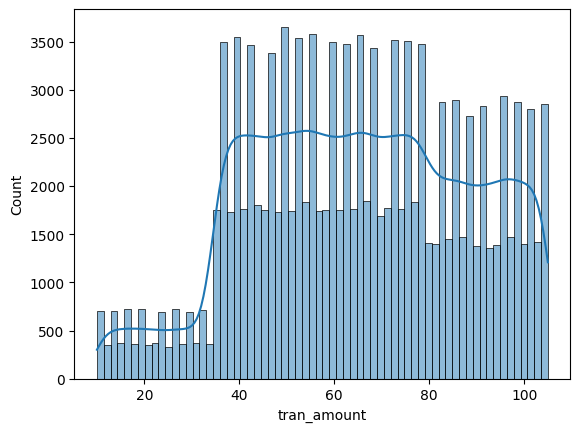

In [14]:
# Checking for outliers

# Histogram
import seaborn as sns
sns.histplot(df.tran_amount, kde = True)

# tran_amount is uniformly distributed

In [15]:
# IQR

Q1 = df['tran_amount'].quantile(0.25)
Q3 = df['tran_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outlier = df[(df['tran_amount'] < lower_fence) | (df['tran_amount'] > upper_fence)]
print(outlier)

# shows there are no outliers

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [16]:
# Z-score

from scipy import stats
import numpy as np

# Calculate Z-score

zscore = np.abs(stats.zscore(df['tran_amount']))

# set a threshold

threshold = 3
outlier = df[zscore > 3]
print(outlier)

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


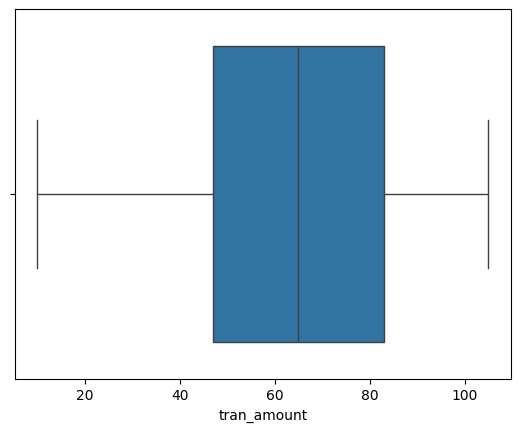

In [17]:
# Box plot

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = df['tran_amount'])
plt.show()

# Feature Engineering

In [18]:
# adding new columns to the dataset

df['month'] = df['trans_date'].dt.month_name()
df

,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1,February
1,CS4768,2015-03-15,39,1,March
2,CS2122,2013-02-26,52,0,February
3,CS1217,2011-11-16,99,0,November
4,CS1850,2013-11-20,78,0,November
...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,June
124996,CS7232,2014-08-19,38,0,August
124997,CS8731,2014-11-28,42,0,November
124998,CS8133,2013-12-14,13,0,December


In [19]:
# Which 3 months have had the highest transaction amounts

monthly_sales = df.groupby('month').agg({'tran_amount':'sum'})
monthly_sales.sort_values(by='tran_amount', ascending = False)[:3].reset_index()

,month,tran_amount
0,August,726775
1,October,725058
2,January,724089


In [20]:
# Customers having highest number of orders

cust_count = df['customer_id'].value_counts().reset_index()

top_5_cust = cust_count.sort_values(by='count', ascending = False)[:5]
top_5_cust

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS3805,35
4,CS1215,35


<Axes: xlabel='customer_id', ylabel='count'>

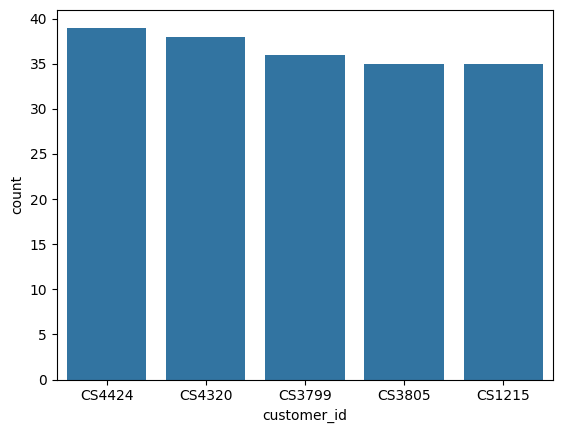

In [21]:
sns.barplot(data = top_5_cust, x = 'customer_id', y = 'count')

In [22]:
# Customers having highest value of orders

cust_sales = df.groupby('customer_id').agg({'tran_amount':'sum'}).reset_index()

top_5_val = cust_sales.sort_values(by='tran_amount', ascending= False)[:5]
top_5_val

,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513


<Axes: xlabel='customer_id', ylabel='tran_amount'>

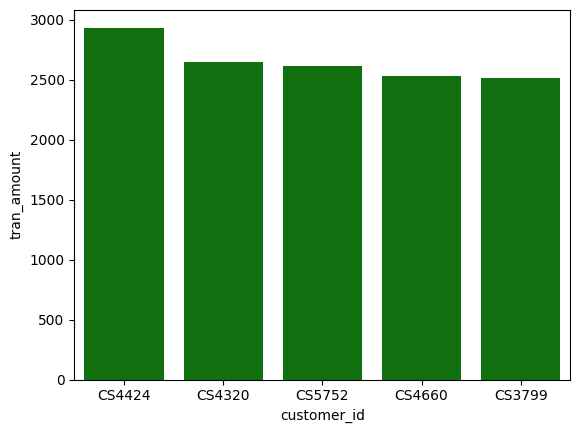

In [23]:
sns.barplot(data= top_5_val, x = 'customer_id', y= 'tran_amount', color= 'green')

# Advance Analytics

## Time Series Analysis

NameError: name 'mdates' is not defined

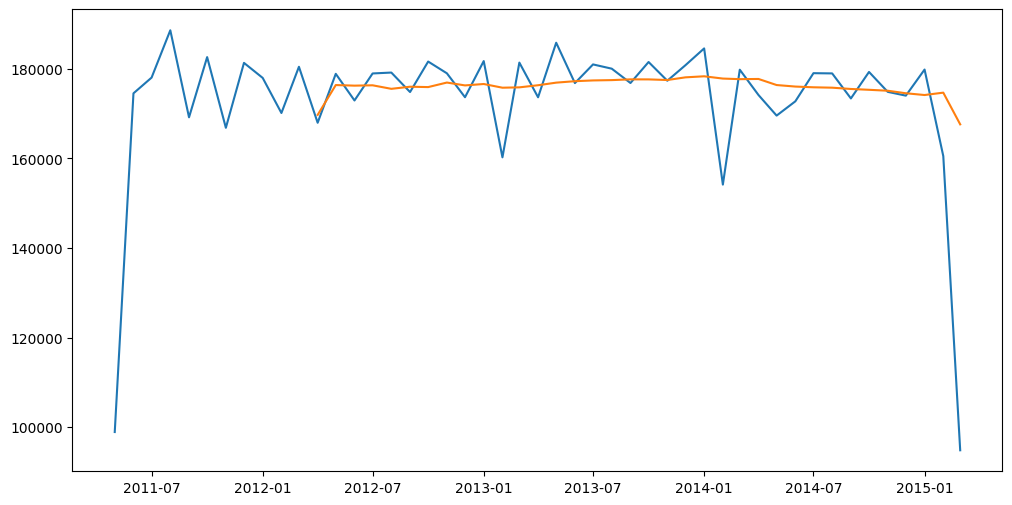

In [24]:
import matplotlib.pyplot as plt

# Creating month-year column
df['month_year'] = df['trans_date'].dt.to_period('M')

# Calculating Monthly sales 
monthly_sales = df.groupby('month_year')['tran_amount'].sum()

# Converting period to timestamp
monthly_sales.index = monthly_sales.index.to_timestamp()

# Rolling average (last 3 months)
rolling_avg = monthly_sales.rolling(window=12).mean()

# Plotting the data
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(rolling_avg, label='12-Month Avg')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Formatting the x-axis labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Setting the x-axis interval
plt.xticks(rotation=45)

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales')

plt.legend()
plt.show()

## Cohort Segmentation

In [25]:
# Calculating recency; i.e. maximum of trans_date
recency = df.groupby('customer_id')['trans_date'].max()

# Calculating frequency; i.e. total no. of transactions
frequency = df.groupby('customer_id')['trans_date'].count()

# Calculating monetary; i.e. total tran_amount
monetary = df.groupby('customer_id')['tran_amount'].sum()

# Creating a dataframe by combining all 3
rfm = pd.DataFrame({'recency': recency, 'frequency': frequency, 'monetary': monetary})
rfm

,recency,frequency,monetary
customer_id,,,
CS1112,2015-01-14,15,1012
CS1113,2015-02-09,20,1490
CS1114,2015-02-12,19,1432
CS1115,2015-03-05,22,1659
CS1116,2014-08-25,13,857
...,...,...,...
CS8996,2014-12-09,13,582
CS8997,2014-06-28,14,543
CS8998,2014-12-22,13,624


In [26]:
#Customer Segmentation

def segment_customer(row):
    if row['recency'].year >=2012 and row['frequency'] >=15 and row['monetary'] >=1000:
        return 'P0'
    elif (2011 >= row['recency'].year < 2012) and (10 > row['frequency'] < 15) and (500 > row['monetary'] < 1000):
        return 'P1'
    else:
        return 'P2'

rfm['segment'] = rfm.apply(segment_customer, axis= 1)
rfm

,recency,frequency,monetary,segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0
CS1113,2015-02-09,20,1490,P0
CS1114,2015-02-12,19,1432,P0
CS1115,2015-03-05,22,1659,P0
CS1116,2014-08-25,13,857,P2
...,...,...,...,...
CS8996,2014-12-09,13,582,P2
CS8997,2014-06-28,14,543,P2
CS8998,2014-12-22,13,624,P2


In [27]:
set(rfm['segment'])

{'P0', 'P2'}

In [28]:
# High-Value / Loyal Customers

(rfm['segment'] == 'P0').sum()

np.int64(4424)

In [29]:
# Low-Value / At-Risk Customers

(rfm['segment'] == 'P2').sum()

np.int64(2460)

## Churn Analysis

<Axes: xlabel='response'>

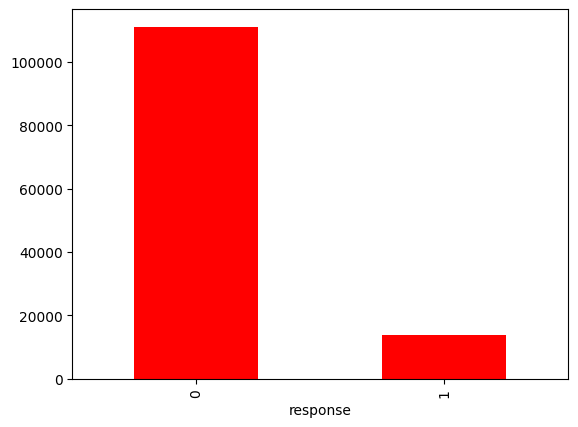

In [30]:
# Counting the number of churned and active customers
churn_count = df['response'].value_counts()

churn_count.plot(kind= 'bar', color= 'red')

In [31]:
# Identifying customers whose last purchase was more than a year

rfm[rfm['recency'].dt.year.isin([2011,2012, 2013])].reset_index()

,customer_id,recency,frequency,monetary,segment
0,CS1314,2013-10-13,13,891,P2
1,CS1481,2013-12-23,13,876,P2
2,CS2011,2013-10-17,14,1078,P2
3,CS2307,2013-12-23,16,1207,P0
4,CS3684,2013-11-01,15,1008,P0
5,CS4419,2013-12-21,16,1177,P0
6,CS4919,2013-12-03,13,863,P2
7,CS5286,2013-05-26,8,579,P2
8,CS7125,2013-12-12,8,447,P2
9,CS7165,2013-12-01,7,341,P2


## Analyzing Top Customers

In [32]:
top_5_customers = monetary.sort_values(ascending=False).head(5)
top_5_customers

customer_id
CS4424    2933
CS4320    2647
CS5752    2612
CS4660    2527
CS3799    2513
Name: tran_amount, dtype: int64

<Axes: xlabel='month_year'>

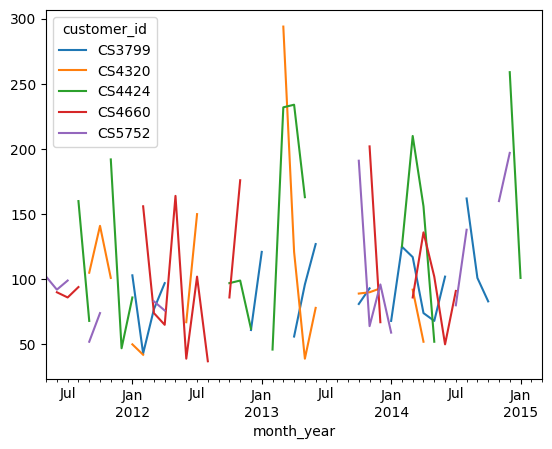

In [33]:
# Top 5 customers
top_5_customers = monetary.sort_values(ascending=False).head(5).index

# Filter transactions of top 5 customers
top_customers_df = df[df['customer_id'].isin(top_5_customers)]

# Plot their monthly sales
top_customers_sales = top_customers_df.groupby(['customer_id', 'month_year'])['tran_amount'].sum().unstack(level=0)
top_customers_sales.plot(kind='line')